Nyquist frequency: 500.0


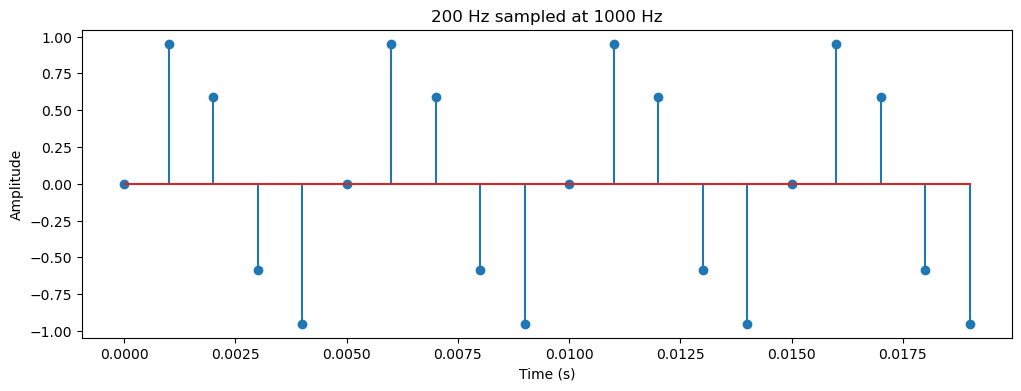

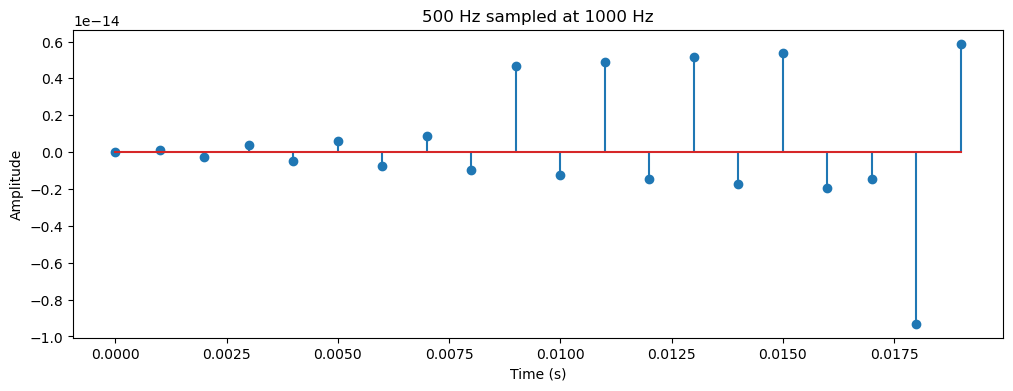

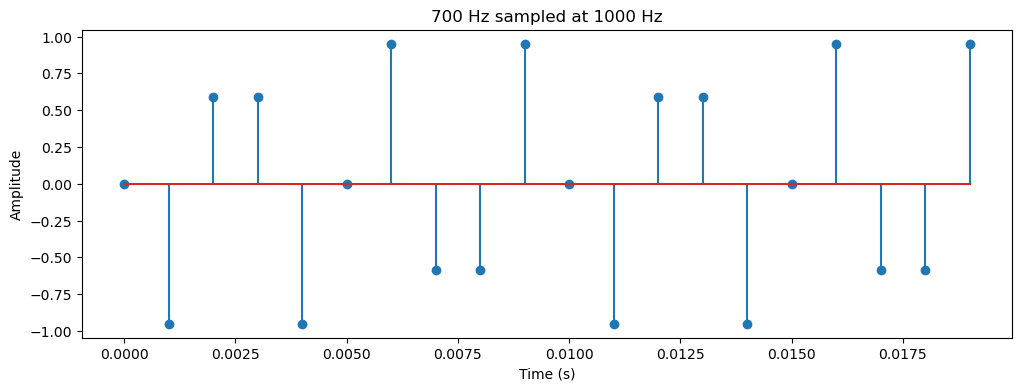

In [1]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1000
duration = 0.02

N = int(sample_rate * duration)
time = np.arange(N) / sample_rate

freq_good = 200
freq_nyquist = 500
freq_alias = 700

signal_good = np.sin(
    2 * np.pi * freq_good * time
)

signal_nyquist = np.sin(
    2 * np.pi * freq_nyquist * time
)

signal_alias = np.sin(
    2 * np.pi * freq_alias * time
)

print(
    "Nyquist frequency:",
    sample_rate / 2
)

plt.figure(figsize=(12, 4))
plt.stem(time, signal_good)
plt.title("200 Hz sampled at 1000 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12, 4))
plt.stem(time, signal_nyquist)
plt.title("500 Hz sampled at 1000 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12, 4))
plt.stem(time, signal_alias)
plt.title("700 Hz sampled at 1000 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
"""
Nyquist Theorem

The Nyquist theorem tells us how fast we need to sample a continuous-time signal
in order to represent it correctly without aliasing.

Core rule:

    fs > 2 * f_max

where:

    fs     = sampling rate
    f_max  = highest frequency present in the signal

This means the sampling rate must be greater than twice the highest frequency
we want to preserve.

1. Nyquist frequency

Given a sampling rate fs, the highest frequency that can be represented without
aliasing is approximately:

    f_N = fs / 2

This is called the Nyquist frequency.

Example:

    fs = 16000 Hz

Then:

    Nyquist frequency = 8000 Hz

So a 16 kHz sampled signal can represent frequencies below about 8 kHz.

2. Why do we need at least two samples per cycle?

A frequency tells us how many cycles happen per second.

For example:

    300 Hz = 300 cycles per second

If we sampled a sinusoid only once per cycle, we could repeatedly sample the same
phase position.

The samples might even appear constant, so we would not be able to identify the
oscillation correctly.

Therefore, we need at least roughly two samples per cycle to represent a sinusoidal
frequency uniquely.

3. Why is exactly two samples per cycle problematic?

Suppose:

    signal frequency = 500 Hz
    fs = 1000 Hz

Then:

    samples per cycle = 1000 / 500 = 2

For a sine wave:

    x(t) = sin(2 * pi * 500 * t)

Sampling at:

    t_n = n / 1000

gives:

    x[n] = sin(2 * pi * 500 * n / 1000)
         = sin(pi * n)

For every integer n:

    sin(pi * n) = 0

Therefore, the sampled signal can become:

    0, 0, 0, 0, ...

even though the original analog signal contains a 500 Hz sinusoid.

The exact result depends on phase, but this shows why operating exactly at the
Nyquist boundary is unsafe.

In practice, we want:

    fs > 2 * f_max

with some margin.

4. Nyquist frequency vs Nyquist rate

These terms are related but different.

Nyquist frequency:

    f_N = fs / 2

It answers:

    "Given my sampling rate, what is the highest frequency I can represent?"

Example:

    fs = 16000 Hz

    Nyquist frequency = 8000 Hz


Nyquist rate:

    Nyquist rate = 2 * f_max

It answers:

    "Given the highest frequency in my signal, what is the minimum theoretical
    sampling rate required?"

Example:

    f_max = 8000 Hz

    Nyquist rate = 16000 Hz


So:

    Nyquist frequency depends on the sampling rate.

    Nyquist rate depends on the highest signal frequency.

5. Connection to aliasing

Suppose:

    fs = 16000 Hz

Then:

    Nyquist frequency = 8000 Hz

If the original signal contains a component at:

    10000 Hz

then 10000 Hz lies above the Nyquist frequency.

After sampling, it can appear as an incorrect lower frequency.

This is aliasing.

Therefore:

    frequencies above fs / 2 must be removed before sampling

if we want to avoid aliasing.

6. Why 16 kHz is common in speech ML

For:

    fs = 16000 Hz

the Nyquist frequency is:

    8000 Hz

A large amount of useful speech information lies below 8 kHz, so 16 kHz is a
common sampling rate for speech recognition and other speech ML systems.

Music and higher-fidelity audio often use:

    44100 Hz
    48000 Hz

which give Nyquist frequencies of:

    22050 Hz
    24000 Hz

respectively.

7. Relationship with samples per cycle

For a frequency f sampled at fs:

    samples_per_cycle = fs / f

Example:

    fs = 16000 Hz
    f = 1000 Hz

Then:

    samples_per_cycle = 16000 / 1000
                      = 16

So every 1 kHz cycle is represented using 16 samples.

As the signal frequency approaches the Nyquist frequency, the number of samples
per cycle approaches 2.

Example:

    fs = 16000 Hz
    f = 8000 Hz

Then:

    samples_per_cycle = 2

This is the limiting case.

8. Key ideas

    Nyquist frequency = fs / 2

    Nyquist rate = 2 * f_max

    To avoid aliasing:

        fs > 2 * f_max

    Higher frequencies require higher sampling rates.

    Frequencies above the Nyquist frequency cannot be uniquely represented.

    Aliasing occurs when those high frequencies fold into lower frequencies.

This leads naturally into resampling, because changing the sampling rate changes
the Nyquist frequency.

For example:

    48000 Hz -> 16000 Hz

changes the Nyquist frequency from:

    24000 Hz -> 8000 Hz

Therefore, downsampling requires special care for frequencies above the new
Nyquist limit.
"""

Original sample rate: 48000
Original samples: 48000
Original duration: 1.0

New sample rate: 16000
New samples: 16000
New duration: 1.0


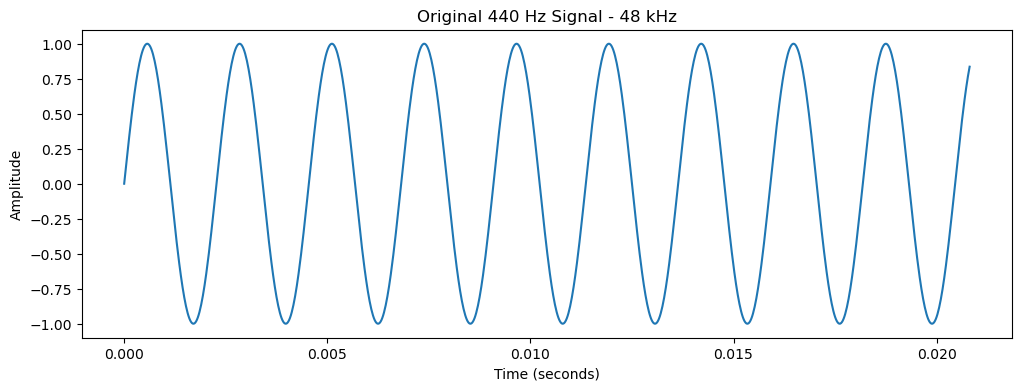

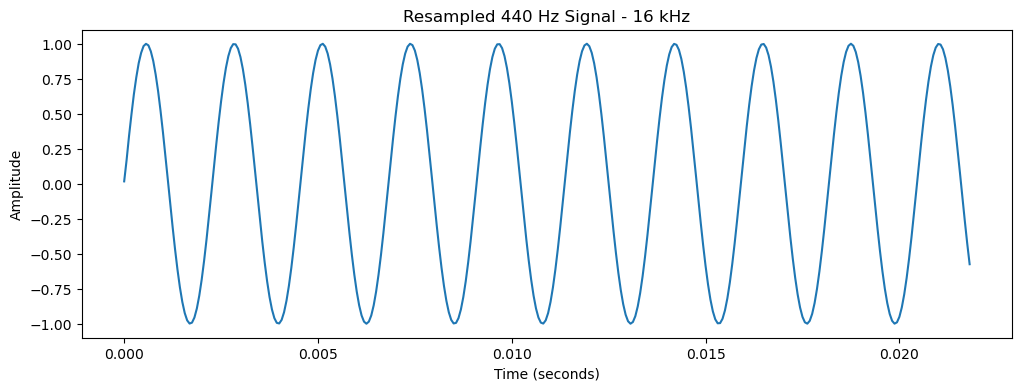

In [3]:
import numpy as np 

import matplotlib.pyplot as plt

import librosa

original_sr = 48000
target_sr = 16000

duration = 1.0
frequency = 440

N = int(original_sr * duration)

time = np.arange(N) / original_sr

signal = np.sin(
    2 * np.pi * frequency * time
)

print("Original sample rate:", original_sr)
print("Original samples:", len(signal))
print(
    "Original duration:",
    len(signal) / original_sr
)

#resampling the signal to a 16khz signal 

resampled_signal = librosa.resample(
    signal,
    orig_sr=original_sr,
    target_sr=target_sr
)

print()

print("New sample rate:", target_sr)
print("New samples:", len(resampled_signal))
print(
    "New duration:",
    len(resampled_signal) / target_sr
)

# --------------------------------------------------
# Time axis for new signal
# --------------------------------------------------

new_time = (
    np.arange(len(resampled_signal))
    / target_sr
)

# --------------------------------------------------
# Plot original
# --------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    time[:1000],
    signal[:1000]
)

plt.title("Original 440 Hz Signal - 48 kHz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# --------------------------------------------------
# Plot resampled
# --------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    new_time[:350],
    resampled_signal[:350]
)

plt.title("Resampled 440 Hz Signal - 16 kHz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
"""
no of cycles are same as signal is 440Hz
only thing that changes is total no of samples describing the cycles
48 kHz:
many samples describing each cycle

16 kHz:
fewer samples describing the same cycle


12. Why do audio ML pipelines resample?
Because datasets often contain mixed sample rates.
For example:
file A -> 44.1 kHz
file B -> 48 kHz
file C -> 16 kHz

But the model usually expects one fixed sample rate:
sample_rate = 16000


So preprocessing converts everything to the same rate: 16KHz


"""

In [ ]:
"""
Downsampling, Upsampling, and Interpolation

1. Downsampling

Downsampling means reducing the sampling rate of a digital signal.

Example:

    48000 Hz -> 16000 Hz

For a 1-second signal:

    48000 Hz -> 48000 samples
    16000 Hz -> 16000 samples

The signal duration remains the same, but fewer samples are used to represent it.

A simple way to think about it is:

    keep fewer samples per second

However, proper downsampling usually requires filtering before samples are removed,
otherwise high-frequency components may alias into lower frequencies.


2. Upsampling

Upsampling means increasing the sampling rate of a digital signal.

Example:

    16000 Hz -> 48000 Hz

For a 1-second signal:

    16000 Hz -> 16000 samples
    48000 Hz -> 48000 samples

The duration remains the same, but more samples are now required.

The original recording does not contain these extra sample values, so they must be
estimated from the existing samples.

This estimation process is called interpolation.


3. Interpolation

Interpolation estimates new sample values between existing samples.

Suppose the original samples are:

    1       3       5

After increasing the sampling rate, we may need additional values:

    1   ?   3   ?   5

A simple interpolation method could estimate:

    1   2   3   4   5

The values 2 and 4 were not originally recorded.

They were estimated from neighboring samples.

Real audio resampling uses more sophisticated interpolation and filtering than this
simple linear example.


4. Important idea

Upsampling creates more sample points, but it does not create new original audio
information.

For example:

    16 kHz -> 48 kHz

increases the number of samples, but it does not magically recover frequency
content that was missing from the original 16 kHz recording.


Summary:

    Downsampling:
        higher sample rate -> lower sample rate
        fewer samples per second

    Upsampling:
        lower sample rate -> higher sample rate
        more samples per second

    Interpolation:
        estimates the additional sample values needed during upsampling
"""

In [4]:
#Naive Downsampling
#The 10 kHz component is now unsafe and can alias into 6 kHz. fn for 48khz to 16khz = fs - f = |10 - 16| = 6Khz
import numpy as np

original_sr = 48000
target_sr = 16000
duration = 1.0

time = np.arange(
    int(original_sr * duration)
) / original_sr

signal = (
    np.sin(2 * np.pi * 3000 * time)
    +
    np.sin(2 * np.pi * 10000 * time)
)

# Naive 48k -> 16k
naive_downsampled = signal[::3]

print(len(signal))
print(len(naive_downsampled))

48000
16000


In [ ]:
#proper way
import librosa

safe_signal = librosa.resample(
    signal,
    orig_sr=48000,
    target_sr=16000
)

In [ ]:
"""
Why does a 10 kHz signal alias to 6 kHz when sampled at 16 kHz?

Suppose:

    fs = 16000 Hz
    signal frequency = 10000 Hz

The Nyquist frequency is:

    fs / 2 = 8000 Hz

So 10 kHz is above Nyquist and cannot be represented uniquely.

The sampled signal is:

    x[n] = sin(2 * pi * (10000 / 16000) * n)

Now:

    10000 / 16000
    = 1 - 6000 / 16000

Therefore:

    x[n]
    = sin(2 * pi * n - 2 * pi * (6000 / 16000) * n)

For integer n, the term:

    2 * pi * n

is a whole number of complete rotations, so it does not change the sampled value.

Therefore:

    x[n]
    = sin(-2 * pi * (6000 / 16000) * n)

Using:

    sin(-theta) = -sin(theta)

we get:

    x[n]
    = -sin(2 * pi * (6000 / 16000) * n)

So the samples produced by a 10 kHz signal at a 16 kHz sampling rate are
equivalent to an inverted 6 kHz sinusoid.

Therefore:

    10 kHz -> -6 kHz -> 6 kHz alias


Why do we subtract from fs = 16 kHz instead of directly from Nyquist = 8 kHz?

In discrete-time signals, frequencies repeat every sampling rate:

    f is equivalent to f +/- k * fs

where k is any integer.

So:

    10 kHz - 16 kHz = -6 kHz

The sampled system therefore sees 10 kHz as -6 kHz.

For a real-valued sinusoid, -6 kHz and +6 kHz represent the same oscillation
frequency, differing only in phase/sign.

That is why the observed alias is:

    6 kHz


Nyquist interpretation

Nyquist is still useful as the folding point.

For:

    fs = 16 kHz

Nyquist is:

    8 kHz

The original signal is:

    10 kHz

which is:

    2 kHz above Nyquist

So it reflects 2 kHz below Nyquist:

    8 kHz - 2 kHz = 6 kHz

Therefore:

    10 kHz -> 6 kHz

Both interpretations are equivalent.

The deeper mathematical reason is that sampled frequencies are periodic with
period fs.

The Nyquist-frequency view is a convenient way to visualize that folding.


Key idea:

    fs controls the repetition of discrete-time frequencies.

    fs / 2 is the edge of the unique representable frequency range.

So:

    10 kHz sampled at 16 kHz
        ->
    equivalent to -6 kHz
        ->
    observed as a 6 kHz alias.
"""